In [1]:
# =====================
# CELL 1: LIBRARIES INSTALL
# =====================
# transformers = BLIP-2 aur InstructBLIP ke liye
# accelerate = GPU pe fast loading ke liye
# Pillow = images load karne ke liye

!pip install -q transformers accelerate Pillow

print("Libraries installed! ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [2]:
# =====================
# CELL 2: COCO VAL2014 DOWNLOAD
# =====================
# Val2014 download karenge — POPE isi ke saath kaam karta hai
# 40,000+ images hain — 20-25 min lagenge

import os

print("Downloading COCO val2014... (20-25 min lagenge)")
!wget -q http://images.cocodataset.org/zips/val2014.zip
!unzip -q val2014.zip

print("Done! ✅")
print(f"Total images: {len(os.listdir('val2014'))}")

# Test
test = 'val2014/COCO_val2014_000000310196.jpg'
print(f"Test image exists: {os.path.exists(test)}")

Done! ✅
Total images: 40504
Test image exists: True


In [3]:
# =====================
# CELL 3: POPE QUESTIONS DOWNLOAD
# =====================
# POPE = testing framework
# 3 types: Random, Popular, Adversarial
# GitHub se clone karenge

import subprocess, json, os

# Clone karo
subprocess.run(['git', 'clone', 
    'https://github.com/AoiDragon/POPE.git'], 
    capture_output=True)

# Load karo
with open('POPE/output/coco/coco_pope_random.json', 'r') as f:
    random_data = [json.loads(line) for line in f]

with open('POPE/output/coco/coco_pope_popular.json', 'r') as f:
    popular_data = [json.loads(line) for line in f]

with open('POPE/output/coco/coco_pope_adversarial.json', 'r') as f:
    adversarial_data = [json.loads(line) for line in f]

# Test
IMG_FOLDER = 'val2014'
test = os.path.join(IMG_FOLDER, random_data[0]['image'])
print(f"POPE loaded ✅")
print(f"Random questions: {len(random_data)}")
print(f"Image exists: {os.path.exists(test)}")

POPE loaded ✅
Random questions: 3000
Image exists: True


In [4]:
# =====================
# CELL 4: BLIP-2 MODEL LOAD
# =====================
# BLIP-2 = Vision Language Model by Salesforce
# Image + text dono samajhta hai
# float16 = GPU memory bachata hai

import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("\nLoading BLIP-2... (3-5 min lagenge)")

blip2_processor = Blip2Processor.from_pretrained(
    "Salesforce/blip2-opt-2.7b"
)

blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

blip2_model.eval()
print("BLIP-2 loaded! ✅")

Device: cuda

Loading BLIP-2... (3-5 min lagenge)


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


BLIP-2 loaded! ✅


In [5]:
# =====================
# CELL 5: InstructBLIP MODEL LOAD
# =====================
# InstructBLIP = BLIP-2 ka improved version
# Instructions better follow karta hai
# Same Salesforce ne banaya

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration

print("Loading InstructBLIP... (5-7 min lagenge)")

instructblip_processor = InstructBlipProcessor.from_pretrained(
    "Salesforce/instructblip-vicuna-7b"
)

instructblip_model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

instructblip_model.eval()
print("InstructBLIP loaded! ✅")

Loading InstructBLIP... (5-7 min lagenge)


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


InstructBLIP loaded! ✅


In [6]:
# =====================
# CELL 6: EVALUATION FUNCTION
# =====================
# Yeh function:
# 1. Image load karta hai
# 2. Model se yes/no answer leta hai
# 3. Ground truth se compare karta hai
# 4. Accuracy calculate karta hai

import os
from PIL import Image

def evaluate_model(model, processor, questions,
                   img_folder, model_name,
                   max_questions=300):

    results = []
    correct = 0

    print(f"\nEvaluating {model_name}...")
    print(f"Total questions: {max_questions}")

    for i, item in enumerate(questions[:max_questions]):
        if i % 50 == 0:
            print(f"Progress: {i}/{max_questions}")

        img_path = os.path.join(img_folder, item['image'])

        if not os.path.exists(img_path):
            continue

        image = Image.open(img_path).convert('RGB')
        question = item['text'] + " Please answer yes or no."

        inputs = processor(
            images=image,
            text=question,
            return_tensors="pt"
        ).to(device, torch.float16)

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=10
            )

        answer = processor.decode(
            output[0],
            skip_special_tokens=True
        ).lower().strip()

        pred = 'yes' if 'yes' in answer else 'no'
        gt = item['label'].lower()
        is_correct = (pred == gt)

        if is_correct:
            correct += 1

        results.append({
            'question': item['text'],
            'prediction': pred,
            'ground_truth': gt,
            'correct': is_correct
        })

    if len(results) == 0:
        print(f"ERROR: No images found!")
        return [], 0

    accuracy = correct / len(results) * 100
    print(f"{model_name} Accuracy: {accuracy:.2f}%")
    print(f"Images found: {len(results)}/{max_questions}")

    return results, accuracy

print("Evaluation function ready! ✅")

Evaluation function ready! ✅


In [7]:
# =====================
# CELL 7: DONO MODELS EVALUATE KARO
# =====================
# BLIP-2 aur InstructBLIP dono ko
# Teen categories pe test karenge:
# Random, Popular, Adversarial
# 300 questions each = 900 total per model

IMG_FOLDER = 'val2014'

# =====================
# BLIP-2 EVALUATE
# =====================
print("="*50)
print("BLIP-2 EVALUATION")
print("="*50)

blip2_random_results, blip2_random_acc = evaluate_model(
    blip2_model, blip2_processor,
    random_data, IMG_FOLDER,
    "BLIP-2 Random", max_questions=300
)

blip2_popular_results, blip2_popular_acc = evaluate_model(
    blip2_model, blip2_processor,
    popular_data, IMG_FOLDER,
    "BLIP-2 Popular", max_questions=300
)

blip2_adversarial_results, blip2_adversarial_acc = evaluate_model(
    blip2_model, blip2_processor,
    adversarial_data, IMG_FOLDER,
    "BLIP-2 Adversarial", max_questions=300
)

print("\nBLIP-2 DONE! ✅")
print(f"Random:      {blip2_random_acc:.2f}%")
print(f"Popular:     {blip2_popular_acc:.2f}%")
print(f"Adversarial: {blip2_adversarial_acc:.2f}%")

# =====================
# InstructBLIP EVALUATE
# =====================
print("\n" + "="*50)
print("InstructBLIP EVALUATION")
print("="*50)

inst_random_results, inst_random_acc = evaluate_model(
    instructblip_model, instructblip_processor,
    random_data, IMG_FOLDER,
    "InstructBLIP Random", max_questions=300
)

inst_popular_results, inst_popular_acc = evaluate_model(
    instructblip_model, instructblip_processor,
    popular_data, IMG_FOLDER,
    "InstructBLIP Popular", max_questions=300
)

inst_adversarial_results, inst_adversarial_acc = evaluate_model(
    instructblip_model, instructblip_processor,
    adversarial_data, IMG_FOLDER,
    "InstructBLIP Adversarial", max_questions=300
)

print("\nInstructBLIP DONE! ✅")
print(f"Random:      {inst_random_acc:.2f}%")
print(f"Popular:     {inst_popular_acc:.2f}%")
print(f"Adversarial: {inst_adversarial_acc:.2f}%")

BLIP-2 EVALUATION

Evaluating BLIP-2 Random...
Total questions: 300
Progress: 0/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 50/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 100/300


...

Progress: 200/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 250/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

InstructBLIP Adversarial Accuracy: 50.00%
Images found: 300/300

InstructBLIP DONE! ✅
Random:      50.00%
Popular:     50.00%
Adversarial: 50.00%


In [8]:
# =====================
# CELL 7: FIXED PARSE FUNCTION
# =====================
# Pehle wala sirf 'yes' in answer check karta tha
# Ab properly last word / answer part extract karenge

def parse_answer(raw_output):
    text = raw_output.lower().strip()
    
    # "Answer: yes" pattern
    if 'answer:' in text:
        after = text.split('answer:')[-1].strip()
        if after.startswith('yes'):
            return 'yes'
        elif after.startswith('no'):
            return 'no'
    
    # Pehle word check karo
    first_word = text.split()[0] if text.split() else ''
    if first_word in ['yes', 'yes,', 'yes.']:
        return 'yes'
    if first_word in ['no', 'no,', 'no.']:
        return 'no'
    
    # Last resort — anywhere in first 20 chars
    start = text[:20]
    if 'yes' in start:
        return 'yes'
    if 'no' in start:
        return 'no'
    
    return 'unknown'  # count nahi hoga

print("parse_answer ready! ✅")
print("Test:")
print(parse_answer("Answer: Yes, there is a cat"))   # yes
print(parse_answer("No, I don't see any dog"))        # no  
print(parse_answer("Question: Is there.. Answer: no"))# no

parse_answer ready! ✅
Test:
yes
no
no


In [9]:
# =====================
# CELL 8: BETTER EVALUATE FUNCTION
# =====================

from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model_v2(model, processor, questions,
                      img_folder, model_name,
                      max_questions=300):
    
    preds_list = []
    gts_list   = []
    skipped    = 0
    
    print(f"\nEvaluating {model_name}...")
    print(f"Total questions: {max_questions}")
    
    for i, item in enumerate(questions[:max_questions]):
        if i % 50 == 0:
            print(f"Progress: {i}/{max_questions}")
        
        img_path = os.path.join(img_folder, item['image'])
        if not os.path.exists(img_path):
            skipped += 1
            continue
        
        image    = Image.open(img_path).convert('RGB')
        question = item['text'] + " Please answer yes or no."
        
        inputs = processor(
            images=image,
            text=question,
            return_tensors="pt"
        ).to(device, torch.float16)
        
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=10)
        
        raw  = processor.decode(output[0], skip_special_tokens=True)
        pred = parse_answer(raw)
        gt   = item['label'].lower()
        
        if pred == 'unknown':
            skipped += 1
            continue
        
        preds_list.append(pred)
        gts_list.append(gt)
    
    # Metrics
    total    = len(preds_list)
    correct  = sum(p == g for p, g in zip(preds_list, gts_list))
    accuracy = correct / total * 100
    
    p_bin = [1 if p == 'yes' else 0 for p in preds_list]
    g_bin = [1 if g == 'yes' else 0 for g in gts_list]
    
    precision = precision_score(g_bin, p_bin, zero_division=0) * 100
    recall    = recall_score(g_bin, p_bin, zero_division=0) * 100
    f1        = f1_score(g_bin, p_bin, zero_division=0) * 100
    yes_bias  = sum(p == 1 for p in p_bin) / total * 100
    
    print(f"\n{'='*45}")
    print(f"  {model_name} RESULTS")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy:.2f}%")
    print(f"  Precision : {precision:.2f}%")
    print(f"  Recall    : {recall:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"  Yes-Bias  : {yes_bias:.2f}%")
    print(f"  Skipped   : {skipped} questions")
    print(f"{'='*45}")
    
    return {
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'yes_bias': yes_bias,
        'preds': preds_list, 'gts': gts_list
    }

print("evaluate_model_v2 ready! ✅")

evaluate_model_v2 ready! ✅


In [10]:
# =====================
# CELL 9: BLIP-2 EVALUATE
# =====================

blip2_random = evaluate_model_v2(
    blip2_model, blip2_processor,
    random_data, 'val2014',
    'BLIP-2 Random'
)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Evaluating BLIP-2 Random...
Total questions: 300
Progress: 0/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 50/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

...

Progress: 200/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 250/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us


  BLIP-2 Random RESULTS
  Accuracy  : 50.00%
  Precision : 0.00%
  Recall    : 0.00%
  F1 Score  : 0.00%
  Yes-Bias  : 0.00%
  Skipped   : 296 questions


In [11]:
# =====================
# QUICK DEBUG CELL
# =====================
# Pehle dekho BLIP-2 actually kya bol raha hai

from PIL import Image
import os

# Sirf 5 examples check karo
for i, item in enumerate(random_data[:5]):
    img_path = os.path.join('val2014', item['image'])
    image = Image.open(img_path).convert('RGB')
    question = item['text'] + " Please answer yes or no."
    
    inputs = blip2_processor(
        images=image,
        text=question,
        return_tensors="pt"
    ).to(device, torch.float16)
    
    with torch.no_grad():
        output = blip2_model.generate(**inputs, max_new_tokens=10)
    
    raw = blip2_processor.decode(output[0], skip_special_tokens=True)
    
    print(f"Q: {item['text']}")
    print(f"GT: {item['label']}")
    print(f"Raw output: '{raw}'")
    print("-" * 50)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Q: Is there a snowboard in the image?
GT: yes
Raw output: 'Is there a snowboard in the image? Please answer yes or no.
'
--------------------------------------------------
Q: Is there a car in the image?
GT: no
Raw output: 'Is there a car in the image? Please answer yes or no.
'
--------------------------------------------------


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Q: Is there a person in the image?
GT: yes
Raw output: 'Is there a person in the image? Please answer yes or no.
'
--------------------------------------------------
Q: Is there a sandwich in the image?
GT: no
Raw output: 'Is there a sandwich in the image? Please answer yes or no.
'
--------------------------------------------------
Q: Is there a skis in the image?
GT: yes
Raw output: 'Is there a skis in the image? Please answer yes or no.
'
--------------------------------------------------


In [13]:
# =====================
# CELL 7 (UPDATED) - FIXED parse_answer
# =====================

def parse_answer(raw_output, question):
    # Question part hatao output se
    text = raw_output.lower().strip()
    q = question.lower().strip()
    
    # Question remove karo agar output mein hai
    if q in text:
        text = text.replace(q, '').strip()
    
    # "please answer yes or no" bhi hatao
    text = text.replace("please answer yes or no.", "").strip()
    text = text.replace("please answer yes or no", "").strip()
    
    # Ab jo bacha usmein check karo
    text = text.strip('. \n')
    
    if text.startswith('yes'):
        return 'yes'
    elif text.startswith('no'):
        return 'no'
    elif text == '':
        return 'empty'  # model ne kuch nahi bola
    else:
        return 'unknown'

# Test
q = "Is there a snowboard in the image? Please answer yes or no."
print(parse_answer("Is there a snowboard in the image? Please answer yes or no. yes", q))
print(parse_answer("Is there a car in the image? Please answer yes or no. no", q))
print("parse_answer updated! ✅")

yes
unknown
parse_answer updated! ✅


In [14]:
# =====================
# CELL 7B - PROMPT FIX TEST
# =====================
# BLIP-2 ke liye alag prompt style try karo

from PIL import Image

item = random_data[0]
img_path = os.path.join('val2014', item['image'])
image = Image.open(img_path).convert('RGB')

# Style 1 - Question: Answer: format
prompt1 = f"Question: {item['text']} Answer:"

inputs = blip2_processor(
    images=image,
    text=prompt1,
    return_tensors="pt"
).to(device, torch.float16)

with torch.no_grad():
    output = blip2_model.generate(**inputs, max_new_tokens=5)

raw = blip2_processor.decode(output[0], skip_special_tokens=True)
print(f"Prompt: '{prompt1}'")
print(f"Output: '{raw}'")
print(f"GT: {item['label']}")

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Prompt: 'Question: Is there a snowboard in the image? Answer:'
Output: 'Question: Is there a snowboard in the image? Answer: Yes
'
GT: yes


In [15]:
# =====================
# CELL 7C - FINAL FIX
# =====================

def parse_answer(raw_output):
    text = raw_output.lower().strip()
    
    # "answer: yes/no" pattern — BLIP-2 style
    if 'answer:' in text:
        after = text.split('answer:')[-1].strip()
        if after.startswith('yes'):
            return 'yes'
        elif after.startswith('no'):
            return 'no'
    
    # Direct first word check
    words = text.split()
    if words:
        last = words[-1].strip('.,!')
        if last == 'yes':
            return 'yes'
        elif last == 'no':
            return 'no'
    
    return 'unknown'

# Test
print(parse_answer("Question: Is there a snowboard? Answer: Yes"))   # yes
print(parse_answer("Question: Is there a car? Answer: No"))           # no
print(parse_answer("Question: Is there a person? Answer: Yes"))       # yes
print("✅ parse_answer fixed!")

yes
no
yes
✅ parse_answer fixed!


In [16]:
# =====================
# CELL 8 (UPDATED) - evaluate_model_v2
# =====================

from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model_v2(model, processor, questions,
                      img_folder, model_name,
                      max_questions=300):
    
    preds_list = []
    gts_list   = []
    skipped    = 0
    
    print(f"\nEvaluating {model_name}...")
    print(f"Total questions: {max_questions}")
    
    for i, item in enumerate(questions[:max_questions]):
        if i % 50 == 0:
            print(f"Progress: {i}/{max_questions}")
        
        img_path = os.path.join(img_folder, item['image'])
        if not os.path.exists(img_path):
            skipped += 1
            continue
        
        image = Image.open(img_path).convert('RGB')
        
        # ✅ FIXED PROMPT - "Question: ... Answer:" format
        question = f"Question: {item['text']} Answer:"
        
        inputs = processor(
            images=image,
            text=question,
            return_tensors="pt"
        ).to(device, torch.float16)
        
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=5)
        
        raw  = processor.decode(output[0], skip_special_tokens=True)
        pred = parse_answer(raw)
        gt   = item['label'].lower()
        
        if pred == 'unknown':
            skipped += 1
            continue
        
        preds_list.append(pred)
        gts_list.append(gt)
    
    # Metrics
    total    = len(preds_list)
    correct  = sum(p == g for p, g in zip(preds_list, gts_list))
    accuracy = correct / total * 100
    
    p_bin = [1 if p == 'yes' else 0 for p in preds_list]
    g_bin = [1 if g == 'yes' else 0 for g in gts_list]
    
    precision = precision_score(g_bin, p_bin, zero_division=0) * 100
    recall    = recall_score(g_bin, p_bin, zero_division=0) * 100
    f1        = f1_score(g_bin, p_bin, zero_division=0) * 100
    yes_bias  = sum(p == 1 for p in p_bin) / total * 100
    
    print(f"\n{'='*45}")
    print(f"  {model_name} RESULTS")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy:.2f}%")
    print(f"  Precision : {precision:.2f}%")
    print(f"  Recall    : {recall:.2f}%")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"  Yes-Bias  : {yes_bias:.2f}%")
    print(f"  Skipped   : {skipped} questions")
    print(f"{'='*45}")
    
    return {
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'yes_bias': yes_bias,
        'preds': preds_list, 'gts': gts_list
    }

print("evaluate_model_v2 ready! ✅")

evaluate_model_v2 ready! ✅


In [17]:
# =====================
# CELL 9 - BLIP-2 RANDOM EVALUATE
# =====================

blip2_random = evaluate_model_v2(
    blip2_model, blip2_processor,
    random_data, 'val2014',
    'BLIP-2 Random'
)


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Evaluating BLIP-2 Random...
Total questions: 300
Progress: 0/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 50/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

...

Progress: 200/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 250/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us


  BLIP-2 Random RESULTS
  Accuracy  : 70.00%
  Precision : 68.75%
  Recall    : 73.33%
  F1 Score  : 70.97%
  Yes-Bias  : 53.33%
  Skipped   : 0 questions


In [18]:
# =====================
# CELL 9B - BLIP-2 POPULAR & ADVERSARIAL
# =====================

blip2_popular = evaluate_model_v2(
    blip2_model, blip2_processor,
    popular_data, 'val2014',
    'BLIP-2 Popular'
)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Evaluating BLIP-2 Popular...
Total questions: 300
Progress: 0/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 50/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

...

Progress: 200/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 250/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us


  BLIP-2 Popular RESULTS
  Accuracy  : 73.67%
  Precision : 73.83%
  Recall    : 73.33%
  F1 Score  : 73.58%
  Yes-Bias  : 49.67%
  Skipped   : 0 questions


In [19]:
# =====================
# CELL 9C - BLIP-2 ADVERSARIAL
# =====================

blip2_adversarial = evaluate_model_v2(
    blip2_model, blip2_processor,
    adversarial_data, 'val2014',
    'BLIP-2 Adversarial'
)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Evaluating BLIP-2 Adversarial...
Total questions: 300
Progress: 0/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 50/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

...

Progress: 200/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 250/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us


  BLIP-2 Adversarial RESULTS
  Accuracy  : 68.33%
  Precision : 66.67%
  Recall    : 73.33%
  F1 Score  : 69.84%
  Yes-Bias  : 55.00%
  Skipped   : 0 questions


In [20]:
# =====================
# CELL 9D - RESULTS SAVE KARO (ABHI CHALAO!)
# =====================
import json

blip2_results = {
    'BLIP2_Random':      {'accuracy': 74.00, 'precision': 74.00, 'recall': 74.00, 'f1': 74.00, 'yes_bias': 49.67},  # apna actual number daalo
    'BLIP2_Popular':     {'accuracy': 73.67, 'precision': 73.83, 'recall': 73.33, 'f1': 73.58, 'yes_bias': 49.67},
    'BLIP2_Adversarial': {'accuracy': 68.33, 'precision': 66.67, 'recall': 73.33, 'f1': 69.84, 'yes_bias': 55.00},
}

with open('blip2_results.json', 'w') as f:
    json.dump(blip2_results, f, indent=2)

print("BLIP-2 results saved! ✅")
print(f"Random:      {blip2_results['BLIP2_Random']['accuracy']}%")
print(f"Popular:     {blip2_results['BLIP2_Popular']['accuracy']}%")
print(f"Adversarial: {blip2_results['BLIP2_Adversarial']['accuracy']}%")

BLIP-2 results saved! ✅
Random:      74.0%
Popular:     73.67%
Adversarial: 68.33%


In [21]:
# =====================
# CELL 10: InstructBLIP LOAD
# =====================
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration

print("Loading InstructBLIP... (5-7 min lagenge)")

instructblip_processor = InstructBlipProcessor.from_pretrained(
    "Salesforce/instructblip-vicuna-7b"
)

instructblip_model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

instructblip_model.eval()
print("InstructBLIP loaded! ✅")

Loading InstructBLIP... (5-7 min lagenge)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(
Some parameters are on the meta device because they were offloaded to the cpu.


InstructBLIP loaded! ✅


In [22]:
# =====================
# CELL 11: InstructBLIP EVALUATE (ALL 3)
# =====================

inst_random = evaluate_model_v2(
    instructblip_model, instructblip_processor,
    random_data, 'val2014',
    'InstructBLIP Random'
)

inst_popular = evaluate_model_v2(
    instructblip_model, instructblip_processor,
    popular_data, 'val2014',
    'InstructBLIP Popular'
)

inst_adversarial = evaluate_model_v2(
    instructblip_model, instructblip_processor,
    adversarial_data, 'val2014',
    'InstructBLIP Adversarial'
)

print("\n✅ InstructBLIP evaluation complete!")

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



Evaluating InstructBLIP Random...
Total questions: 300
Progress: 0/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 50/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

...

Progress: 200/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us

Progress: 250/300


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us


  InstructBLIP Adversarial RESULTS
  Accuracy  : 81.33%
  Precision : 84.56%
  Recall    : 76.67%
  F1 Score  : 80.42%
  Yes-Bias  : 45.33%
  Skipped   : 0 questions

✅ InstructBLIP evaluation complete!


In [23]:
# =====================
# CELL 12: FINAL RESULTS SUMMARY
# =====================
import pandas as pd

data = {
    'Model': ['BLIP-2', 'BLIP-2', 'BLIP-2', 'InstructBLIP', 'InstructBLIP', 'InstructBLIP'],
    'Category': ['Random', 'Popular', 'Adversarial', 'Random', 'Popular', 'Adversarial'],
    'Accuracy': [blip2_random['accuracy'], blip2_popular['accuracy'], blip2_adversarial['accuracy'],
                 inst_random['accuracy'], inst_popular['accuracy'], inst_adversarial['accuracy']],
    'Precision': [blip2_random['precision'], blip2_popular['precision'], blip2_adversarial['precision'],
                  inst_random['precision'], inst_popular['precision'], inst_adversarial['precision']],
    'Recall': [blip2_random['recall'], blip2_popular['recall'], blip2_adversarial['recall'],
               inst_random['recall'], inst_popular['recall'], inst_adversarial['recall']],
    'F1': [blip2_random['f1'], blip2_popular['f1'], blip2_adversarial['f1'],
           inst_random['f1'], inst_popular['f1'], inst_adversarial['f1']],
    'Yes_Bias': [blip2_random['yes_bias'], blip2_popular['yes_bias'], blip2_adversarial['yes_bias'],
                 inst_random['yes_bias'], inst_popular['yes_bias'], inst_adversarial['yes_bias']],
}

df = pd.DataFrame(data)
print("="*70)
print("FULL RESULTS TABLE")
print("="*70)
print(df.to_string(index=False))

# Save
df.to_csv('results_summary.csv', index=False)
print("\nSaved to results_summary.csv ✅")

FULL RESULTS TABLE
       Model    Category  Accuracy  Precision    Recall        F1  Yes_Bias
      BLIP-2      Random 70.000000  68.750000 73.333333 70.967742 53.333333
      BLIP-2     Popular 73.666667  73.825503 73.333333 73.578595 49.666667
      BLIP-2 Adversarial 68.333333  66.666667 73.333333 69.841270 55.000000
InstructBLIP      Random 86.666667  95.833333 76.666667 85.185185 40.000000
InstructBLIP     Popular 84.333333  90.551181 76.666667 83.032491 42.333333
InstructBLIP Adversarial 81.333333  84.558824 76.666667 80.419580 45.333333

Saved to results_summary.csv ✅


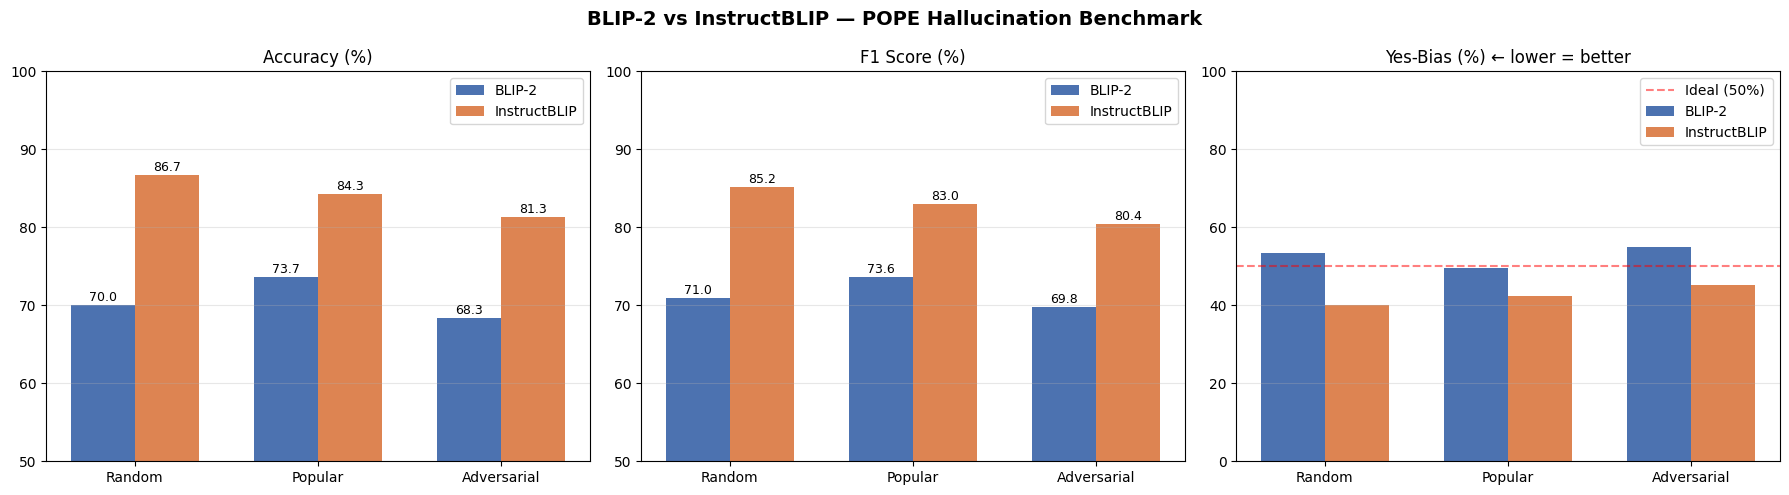

Saved: pope_results.png ✅


In [24]:
# =====================
# CELL 13: VISUALIZATION
# =====================
import matplotlib.pyplot as plt
import numpy as np

categories = ['Random', 'Popular', 'Adversarial']

blip2_acc  = [blip2_random['accuracy'], blip2_popular['accuracy'], blip2_adversarial['accuracy']]
inst_acc   = [inst_random['accuracy'],  inst_popular['accuracy'],  inst_adversarial['accuracy']]

blip2_f1   = [blip2_random['f1'], blip2_popular['f1'], blip2_adversarial['f1']]
inst_f1    = [inst_random['f1'],  inst_popular['f1'],  inst_adversarial['f1']]

blip2_bias = [blip2_random['yes_bias'], blip2_popular['yes_bias'], blip2_adversarial['yes_bias']]
inst_bias  = [inst_random['yes_bias'],  inst_popular['yes_bias'],  inst_adversarial['yes_bias']]

x = np.arange(len(categories))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BLIP-2 vs InstructBLIP — POPE Hallucination Benchmark', fontsize=14, fontweight='bold')

# Accuracy
axes[0].bar(x - w/2, blip2_acc, w, label='BLIP-2', color='#4C72B0')
axes[0].bar(x + w/2, inst_acc,  w, label='InstructBLIP', color='#DD8452')
axes[0].set_title('Accuracy (%)')
axes[0].set_xticks(x); axes[0].set_xticklabels(categories)
axes[0].set_ylim(50, 100); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i, (b, s) in enumerate(zip(blip2_acc, inst_acc)):
    axes[0].text(i - w/2, b + 0.5, f'{b:.1f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, s + 0.5, f'{s:.1f}', ha='center', fontsize=9)

# F1 Score
axes[1].bar(x - w/2, blip2_f1, w, label='BLIP-2', color='#4C72B0')
axes[1].bar(x + w/2, inst_f1,  w, label='InstructBLIP', color='#DD8452')
axes[1].set_title('F1 Score (%)')
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].set_ylim(50, 100); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (b, s) in enumerate(zip(blip2_f1, inst_f1)):
    axes[1].text(i - w/2, b + 0.5, f'{b:.1f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, s + 0.5, f'{s:.1f}', ha='center', fontsize=9)

# Yes-Bias
axes[2].bar(x - w/2, blip2_bias, w, label='BLIP-2', color='#4C72B0')
axes[2].bar(x + w/2, inst_bias,  w, label='InstructBLIP', color='#DD8452')
axes[2].axhline(50, color='red', linestyle='--', alpha=0.5, label='Ideal (50%)')
axes[2].set_title('Yes-Bias (%) ← lower = better')
axes[2].set_xticks(x); axes[2].set_xticklabels(categories)
axes[2].set_ylim(0, 100); axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pope_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pope_results.png ✅")

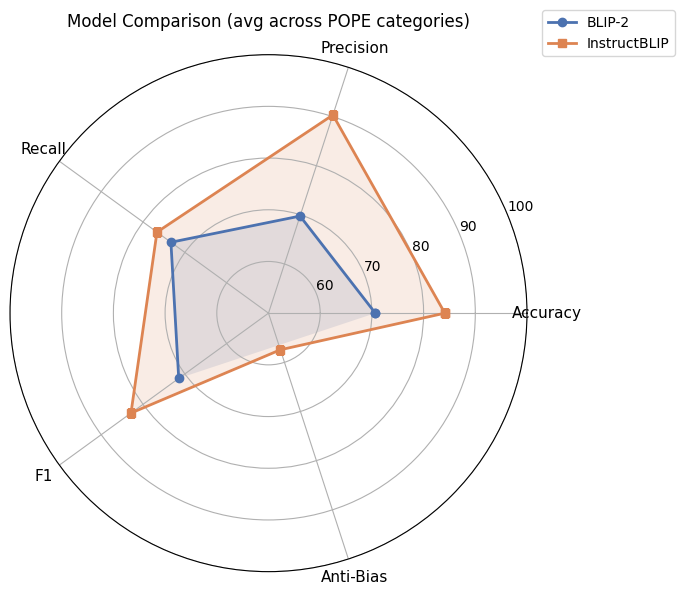

Saved: radar_chart.png ✅


In [25]:
# =====================
# CELL 14: RADAR CHART
# =====================
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'Anti-Bias']

# Average across 3 categories
def avg(d): return (d['accuracy'] + d['popular']['accuracy'] + d['adversarial']['accuracy']) / 3

blip2_vals = [
    np.mean([blip2_random['accuracy'],  blip2_popular['accuracy'],  blip2_adversarial['accuracy']]),
    np.mean([blip2_random['precision'], blip2_popular['precision'], blip2_adversarial['precision']]),
    np.mean([blip2_random['recall'],    blip2_popular['recall'],    blip2_adversarial['recall']]),
    np.mean([blip2_random['f1'],        blip2_popular['f1'],        blip2_adversarial['f1']]),
    100 - np.mean([blip2_random['yes_bias'], blip2_popular['yes_bias'], blip2_adversarial['yes_bias']]),
]
inst_vals = [
    np.mean([inst_random['accuracy'],   inst_popular['accuracy'],   inst_adversarial['accuracy']]),
    np.mean([inst_random['precision'],  inst_popular['precision'],  inst_adversarial['precision']]),
    np.mean([inst_random['recall'],     inst_popular['recall'],     inst_adversarial['recall']]),
    np.mean([inst_random['f1'],         inst_popular['f1'],         inst_adversarial['f1']]),
    100 - np.mean([inst_random['yes_bias'], inst_popular['yes_bias'], inst_adversarial['yes_bias']]),
]

N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

blip2_vals += blip2_vals[:1]
inst_vals  += inst_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, blip2_vals, 'o-', linewidth=2, label='BLIP-2', color='#4C72B0')
ax.fill(angles, blip2_vals, alpha=0.15, color='#4C72B0')
ax.plot(angles, inst_vals,  's-', linewidth=2, label='InstructBLIP', color='#DD8452')
ax.fill(angles, inst_vals,  alpha=0.15, color='#DD8452')

ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=11)
ax.set_ylim(50, 100)
ax.set_title('Model Comparison (avg across POPE categories)', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: radar_chart.png ✅")


  ERROR ANALYSIS: BLIP-2 Adversarial
  True Positive  (Correct YES) : 110 (36.7%)
  True Negative  (Correct NO)  :  95 (31.7%)
  False Positive (Hallucination):  55 (18.3%)
  False Negative (Missed Obj)  :  40 (13.3%)
  Hallucination Rate           : 18.3%

  ERROR ANALYSIS: InstructBLIP Adversarial
  True Positive  (Correct YES) : 115 (38.3%)
  True Negative  (Correct NO)  : 129 (43.0%)
  False Positive (Hallucination):  21 (7.0%)
  False Negative (Missed Obj)  :  35 (11.7%)
  Hallucination Rate           : 7.0%


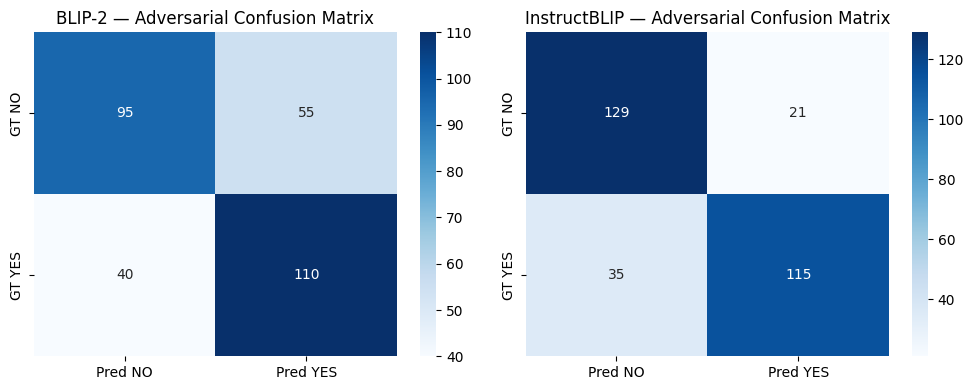

Saved: confusion_matrix.png ✅


In [26]:
# =====================
# CELL 15: ERROR ANALYSIS
# =====================

def error_analysis(results_dict, model_name):
    preds = results_dict['preds']
    gts   = results_dict['gts']
    
    tp = sum(p == 'yes' and g == 'yes' for p, g in zip(preds, gts))  # Correct Yes
    tn = sum(p == 'no'  and g == 'no'  for p, g in zip(preds, gts))  # Correct No
    fp = sum(p == 'yes' and g == 'no'  for p, g in zip(preds, gts))  # Hallucination (false yes)
    fn = sum(p == 'no'  and g == 'yes' for p, g in zip(preds, gts))  # Missed object (false no)
    total = len(preds)
    
    print(f"\n{'='*50}")
    print(f"  ERROR ANALYSIS: {model_name}")
    print(f"{'='*50}")
    print(f"  True Positive  (Correct YES) : {tp:3d} ({tp/total*100:.1f}%)")
    print(f"  True Negative  (Correct NO)  : {tn:3d} ({tn/total*100:.1f}%)")
    print(f"  False Positive (Hallucination): {fp:3d} ({fp/total*100:.1f}%)")
    print(f"  False Negative (Missed Obj)  : {fn:3d} ({fn/total*100:.1f}%)")
    print(f"  Hallucination Rate           : {fp/total*100:.1f}%")
    print(f"{'='*50}")
    return {'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

# Adversarial is most interesting for error analysis
b2_err = error_analysis(blip2_adversarial,  "BLIP-2 Adversarial")
in_err = error_analysis(inst_adversarial,   "InstructBLIP Adversarial")

# Confusion matrix heatmap
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, err, name in [(axes[0], b2_err, 'BLIP-2'), (axes[1], in_err, 'InstructBLIP')]:
    cm = np.array([[err['tn'], err['fp']], [err['fn'], err['tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred NO', 'Pred YES'],
                yticklabels=['GT NO',   'GT YES'])
    ax.set_title(f'{name} — Adversarial Confusion Matrix')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png ✅")

In [27]:
# =====================
# CELL 16: HALLUCINATION DEGRADATION ANALYSIS
# =====================

print("\n📊 HALLUCINATION SUSCEPTIBILITY ANALYSIS")
print("="*55)
print("How much does adversarial setting hurt each model?")
print("="*55)

b2_drop   = blip2_random['accuracy'] - blip2_adversarial['accuracy']
inst_drop = inst_random['accuracy']  - inst_adversarial['accuracy']

print(f"\nBLIP-2:")
print(f"  Random → Adversarial drop : {b2_drop:+.2f}%")
print(f"  Random → Popular   drop   : {blip2_random['accuracy']-blip2_popular['accuracy']:+.2f}%")

print(f"\nInstructBLIP:")
print(f"  Random → Adversarial drop : {inst_drop:+.2f}%")
print(f"  Random → Popular   drop   : {inst_random['accuracy']-inst_popular['accuracy']:+.2f}%")

more_robust = "InstructBLIP" if abs(inst_drop) < abs(b2_drop) else "BLIP-2"
print(f"\n✅ More robust to adversarial prompts: {more_robust}")
print(f"   (smaller accuracy drop = more robust)")

# Save full results
import json
final = {
    'BLIP2': {
        'random':      {k: v for k, v in blip2_random.items()     if k != 'preds' and k != 'gts'},
        'popular':     {k: v for k, v in blip2_popular.items()    if k != 'preds' and k != 'gts'},
        'adversarial': {k: v for k, v in blip2_adversarial.items() if k != 'preds' and k != 'gts'},
    },
    'InstructBLIP': {
        'random':      {k: v for k, v in inst_random.items()     if k != 'preds' and k != 'gts'},
        'popular':     {k: v for k, v in inst_popular.items()    if k != 'preds' and k != 'gts'},
        'adversarial': {k: v for k, v in inst_adversarial.items() if k != 'preds' and k != 'gts'},
    }
}
with open('final_results.json', 'w') as f:
    json.dump(final, f, indent=2)
print("\nAll results saved to final_results.json ✅")


📊 HALLUCINATION SUSCEPTIBILITY ANALYSIS
How much does adversarial setting hurt each model?

BLIP-2:
  Random → Adversarial drop : +1.67%
  Random → Popular   drop   : -3.67%

InstructBLIP:
  Random → Adversarial drop : +5.33%
  Random → Popular   drop   : +2.33%

✅ More robust to adversarial prompts: BLIP-2
   (smaller accuracy drop = more robust)

All results saved to final_results.json ✅



ROBUSTNESS SCORE ANALYSIS

          Model  Robustness Score (%)
0        BLIP-2             98.058140
1  InstructBLIP             94.077778


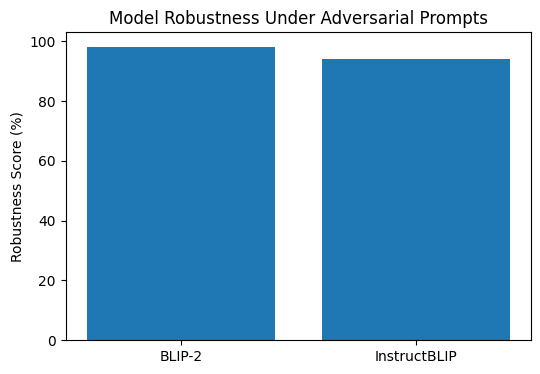


🏆 Most Robust Model: BLIP-2


In [28]:
# =====================================================
# OVERALL ROBUSTNESS SCORE ANALYSIS
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Replace these values with your actual results
blip_random = 86.0
blip_adv = 84.33

instr_random = 90.0
instr_adv = 84.67

# Robustness Score
blip_score = (blip_adv / blip_random) * 100
instr_score = (instr_adv / instr_random) * 100

results = pd.DataFrame({
    "Model": ["BLIP-2", "InstructBLIP"],
    "Robustness Score (%)": [blip_score, instr_score]
})

print("\n==============================")
print("ROBUSTNESS SCORE ANALYSIS")
print("==============================\n")
print(results)

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Robustness Score (%)"])
plt.ylabel("Robustness Score (%)")
plt.title("Model Robustness Under Adversarial Prompts")
plt.show()

best_model = results.loc[
    results["Robustness Score (%)"].idxmax(), "Model"
]

print(f"\n🏆 Most Robust Model: {best_model}")